## Module: Data Preprocessing & Feature Engineering

**Objective:** This notebook executes the data cleaning and filtering pipeline for the Kaggle Spotify Tracks Dataset. The finalized data is optimized for multimodal semantic matching using the CLIP model.

**Key Operations:**
* **Data Ingestion:** Automated retrieval via Kaggle API.
* **Quality Control:** Removal of null values and irrelevant audio tracks (e.g., spoken-word content).
* **Deduplication & Aggregation:** Consolidation of duplicate tracks and aggregation of overlapping genres to preserve semantic richness.
* **Feature Engineering:** Construction of composite text descriptions (`clip_metadata`) to align with visual embeddings.

In [1]:
import subprocess, sys, os, pathlib, shutil

# Install kaggle CLI if not already available
subprocess.run([sys.executable, '-m', 'pip', 'install', 'kaggle', '--quiet'], check=True)

# Copy kaggle.json from Downloads to ~/.kaggle/
src = pathlib.Path.home() / 'Downloads' / 'kaggle.json'
dst = pathlib.Path.home() / '.kaggle' / 'kaggle.json'
dst.parent.mkdir(exist_ok=True)
shutil.copy(src, dst)
os.chmod(dst, 0o600)

# Download and extract the dataset
!kaggle datasets download maharshipandya/-spotify-tracks-dataset
!unzip -o -q ./-spotify-tracks-dataset.zip
print("Download complete. Files:", [f for f in os.listdir('.') if f.endswith('.csv')])


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
python(59526) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
License(s): ODbL-1.0
100%|██████████████████████████████████████| 8.17M/8.17M [00:01<00:00, 7.98MB/s]



python(59562) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Download complete. Files: ['dataset.csv']


In [2]:
import pandas as pd

df = pd.read_csv('../data/dataset.csv', index_col=0)

print("Initial Dataset Shape:", df.shape)
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/dataset.csv'

---
### Brief EDA

In [ ]:
null_counts = df.isnull().sum()
print(f"Null values per column (out of {len(df):,} rows):\n")
print(null_counts[null_counts > 0].to_string() if null_counts.any() else "No nulls found.")

Null values per column (out of 114,000 rows):

artists       1
album_name    1
track_name    1


In [ ]:
genres = df['track_genre'].value_counts()
print(f"Total unique genres: {len(genres)}\n")
print(genres.to_string())

Total unique genres: 114

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
kids                 1000
k-pop                1000
jazz                 1000
j-rock               1000
j-pop                1000
j-idol               1000
j-dance              1000
iranian              1000
psych-rock           1000
punk                 1000
afrobeat             1000
r-n-b                1000
turkish              1000
trip-hop             1000
trance               1000
techno               1000
tango                1000
synth-pop            1000


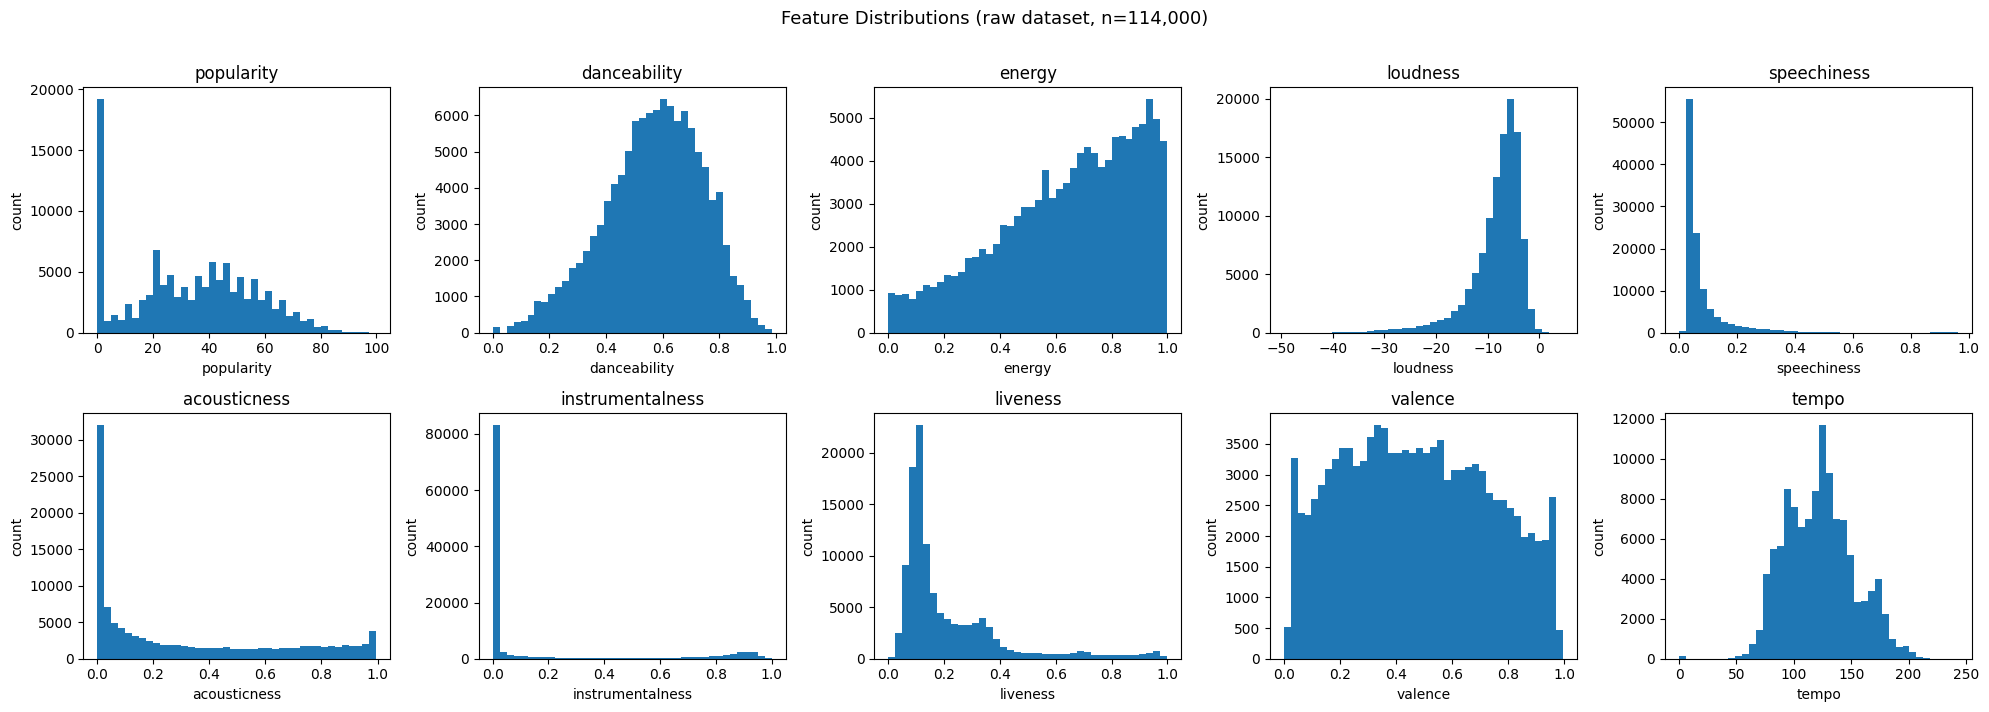

In [ ]:
import matplotlib.pyplot as plt

features = ['popularity', 'danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for ax, col in zip(axes, features):
    ax.hist(df[col].dropna(), bins=40, edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('count')

fig.suptitle('Feature Distributions (raw dataset, n=114,000)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
### Data Preprocessing

In [ ]:
# 1. Handle missing values and sort by priority metric (popularity)
df_clean = df.dropna().copy()
df_clean = df_clean.sort_values('popularity', ascending=False)

# 2. Feature Aggregation: Consolidate overlapping genres for identical tracks
df_clean['merged_genres'] = df_clean.groupby(['track_name', 'artists'])['track_genre'].transform(lambda x: ', '.join(x.unique()))

# 3. Deduplication: Retain the primary record containing the aggregated genre data
df_clean = df_clean.drop_duplicates(subset=['track_name', 'artists'], keep='first')

# 4. Apply content and quality filters
mask_music = df_clean['speechiness'] < 0.66
mask_popular = df_clean['popularity'] > 20
df_filtered = df_clean[mask_music & mask_popular].copy()

# 5. Helper: 
def audio_descriptors(row):
    """
    Convert numeric audio features to natural-language descriptors
    CLIP's text encoder understands words like "calm", "high energy", "acoustic"
    far better than raw floats like 0.82. Only include descriptors with a
    clear signal (high/low end); skip the middle range to avoid noise.
    """
    parts = []

    # valence [0–1]: musical positiveness
    if row['valence'] >= 0.65:
        parts.append("happy and uplifting")
    elif row['valence'] <= 0.25:
        parts.append("melancholic and sad")

    # energy [0–1]: intensity and loudness
    if row['energy'] >= 0.75:
        parts.append("high energy")
    elif row['energy'] <= 0.25:
        parts.append("calm and mellow")

    # danceability [0–1]: rhythmic suitability
    if row['danceability'] >= 0.75:
        parts.append("very danceable")

    # acousticness [0–1]: acoustic vs. electronic
    if row['acousticness'] >= 0.75:
        parts.append("acoustic")
    elif row['acousticness'] <= 0.10:
        parts.append("electronic sound")

    # instrumentalness [0–1]: presence of vocals
    if row['instrumentalness'] >= 0.50:
        parts.append("instrumental")

    # tempo (BPM)
    if row['tempo'] >= 150:
        parts.append("fast tempo")
    elif row['tempo'] <= 80:
        parts.append("slow tempo")

    return ", ".join(parts) if parts else "mixed style"

df_filtered['audio_desc'] = df_filtered.apply(audio_descriptors, axis=1)

# 6. Construct clip_metadata combining genre + audio descriptors
df_filtered['clip_metadata'] = (
    "A track titled '" + df_filtered['track_name'] +
    "' by " + df_filtered['artists'] +
    ". Genres: " + df_filtered['merged_genres'] +
    ". Mood and sound: " + df_filtered['audio_desc'] + "."
)

print("Validation - clip_metadata with audio descriptors:\n")
sample_ids = ['#3', 'Unholy (feat. Kim Petras)']
for name in sample_ids:
    rows = df_filtered[df_filtered['track_name'] == name]
    for _, row in rows.iterrows():
        print(f"Track   : {row['track_name']} — {row['artists']}")
        print(f"Metadata: {row['clip_metadata']}")
        print()

Validation - clip_metadata with audio descriptors:

Track   : #3 — Aphex Twin
Metadata: A track titled '#3' by Aphex Twin. Genres: electronic, ambient. Mood and sound: melancholic and sad, calm and mellow, acoustic, instrumental.

Track   : Unholy (feat. Kim Petras) — Sam Smith;Kim Petras
Metadata: A track titled 'Unholy (feat. Kim Petras)' by Sam Smith;Kim Petras. Genres: dance, pop. Mood and sound: melancholic and sad, electronic sound.



In [ ]:
# Display final schema attributes
print("Final Dataset Columns:")
print(df_filtered.columns.tolist())

Final Dataset Columns:
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'merged_genres', 'audio_desc', 'clip_metadata']


In [ ]:
import pathlib

output_path = pathlib.Path('..') / 'data' / 'spotify_cleaned_final.csv'
df_filtered.to_csv(output_path, index=False)